# Predicting Federal Contract Outcomes Using NLP and Machine Learning

**Authors:** Leonel Lourenco, Rana Khan  
**Course:** IS392 Section 452  
**Institution:** New Jersey Institute of Technology  
**Date:** 3/28/2026

## Purpose
This notebook implements the data pipeline and initial analysis for predicting whether U.S. federal government contracts for physical deliverables will experience cost overruns or schedule delays. It uses contract description text (NLP via LDA topic modeling and TF-IDF) combined with structured contract attributes to train binary classifiers.

## Dataset
Omari et al. Comprehensive Federal Procurement Dataset (1979-2023), published in Scientific Data (Nature, 2025). 99 million contract action records, 470 variables. CC0 license. Source: https://doi.org/10.6084/m9.figshare.28057043

## Expected Outputs
- Filtered dataset of completed physical-deliverable contracts
- Binary outcome labels: over_budget (0/1), late (0/1)
- Exploratory data analysis with visualizations
- Preprocessed text corpus ready for topic modeling (two-track: LDA + TF-IDF)
- Preliminary LDA topic model and TF-IDF feature matrix
- Initial classification results comparing four feature configurations

## 1. Environment Setup and Imports
Import all required libraries and configure display settings. All dependencies are listed in `requirements.txt`.

In [28]:
# Data handling and Parquet file reading
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import os
import glob
import warnings
from pathlib import Path

# Visualization
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning: classifiers, metrics, preprocessing
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer

# NLP: tokenization, stop words, lemmatization
import nltk
from nltk.corpus import stopwords
import spacy

# Topic modeling
from gensim.models import LdaModel, CoherenceModel
from gensim.corpora import Dictionary

# Utilities
from tqdm import tqdm
import re

# Placeholder assigned before spaCy model is loaded in Section 8
nlp = None

# Suppress noisy warnings for cleaner notebook output
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)

# Matplotlib and seaborn styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

# Global reproducibility seed
RANDOM_STATE = 42

# Print package versions for reproducibility
print('Package Versions')
print('-' * 30)
for pkg_name, pkg in [('pandas', pd), ('numpy', np), ('matplotlib', matplotlib),
                       ('seaborn', sns), ('sklearn', __import__('sklearn')),
                       ('nltk', nltk), ('spacy', spacy),
                       ('gensim', __import__('gensim'))]:
    print(f'  {pkg_name}: {pkg.__version__}')

Package Versions
------------------------------
  pandas: 2.3.3
  numpy: 2.4.4
  matplotlib: 3.10.8
  seaborn: 0.13.2
  sklearn: 1.8.0
  nltk: 3.9.4
  spacy: 3.8.2
  gensim: 4.4.0


## 2. Configuration
Define all file paths, filtering criteria, labeling thresholds, and modeling parameters as constants. This centralizes configuration and makes the pipeline easier to modify and reproduce.

In [ ]:
# --- File Paths ---
SHARD_FOLDER = r'C:\\Users\\sarme\\IS392Final\\data'
INTERIM_OUTPUT = r'C:\\Users\\sarme\\IS392Final\\data\\interim\\filtered_physical_deliverables.parquet'
FINAL_OUTPUT = r'C:\\Users\\sarme\\IS392Final\\data\\processed\\labeled_contracts.parquet'
FIGURES_FOLDER = './figures'

# Create output directories if they don't exist
os.makedirs(os.path.dirname(INTERIM_OUTPUT), exist_ok=True)
os.makedirs(os.path.dirname(FINAL_OUTPUT), exist_ok=True)
os.makedirs(FIGURES_FOLDER, exist_ok=True)

# --- Filtering Criteria ---
PHYSICAL_PSC_PREFIXES = ['Y', 'Z']
PHYSICAL_PSC_NUMERIC_RANGE = (10, 99)

# --- Labeling Thresholds ---
COST_OVERRUN_THRESHOLD = 0.05
SCHEDULE_DELAY_THRESHOLD = 0
MIN_DESCRIPTION_LENGTH = 100

# --- Sampling ---
SAMPLE_CONTRACTS = 50_000

# --- Modeling Parameters ---
LDA_NUM_TOPICS = 15
LDA_PASSES = 10
TFIDF_MAX_FEATURES = 5000
TEST_SIZE = 0.20

# --- Exact Parquet Column Mapping ---
COLUMN_MAP = {
    'piid':              'content.ID.ContractID.PIID',
    'mod_number':        'content.ID.ContractID.modNumber',
    'description':       'content.contractData.descriptionOfContractRequirement',
    'psc':               'content.productOrServiceInformation.productOrServiceCode.#text',
    'naics':             'content.productOrServiceInformation.principalNAICSCode.#text',
    'base_all_options':  'content.dollarValues.baseAndAllOptionsValue',
    'base_exercised':    'content.dollarValues.baseAndExercisedOptionsValue',
    'current_completion':'content.relevantContractDates.currentCompletionDate',
    'ultimate_completion':'content.relevantContractDates.ultimateCompletionDate',
    'effective_date':    'content.relevantContractDates.effectiveDate',
    'signed_date':       'content.relevantContractDates.signedDate',
    'reason_for_mod':    'content.contractData.reasonForModification.#text',
    'contract_type':     'content.contractData.typeOfContractPricing.#text',
    'extent_competed':   'content.competition.extentCompeted.#text',
    'num_offers':        'content.competition.numberOfOffersReceived',
    'agency_id':         'content.purchaserInformation.contractingOfficeAgencyID.#text',
    'vendor_name':       'content.vendor.vendorHeader.vendorName',
    'state_code':        'content.placeOfPerformance.principalPlaceOfPerformance.stateCode.#text',
}
COLUMNS_TO_READ = list(COLUMN_MAP.values())

print('Configuration loaded.')
print(f'  Shard folder: {SHARD_FOLDER}')
print(f'  Sample contracts: {SAMPLE_CONTRACTS:,}')
print(f'  Cost overrun threshold: {COST_OVERRUN_THRESHOLD:.0%}')
print(f'  Columns mapped: {len(COLUMN_MAP)}')

Configuration loaded.
  Shard folder: ./data
  Sample contracts: 50,000
  Cost overrun threshold: 5%
  Columns mapped: 18


## 3. Helper Functions
Define reusable functions for filtering, label computation, and text preprocessing.

In [31]:
def is_physical_deliverable(psc_code: str) -> bool:
    """Check if a PSC code indicates physical deliverables."""
    if pd.isna(psc_code):
        return False
    psc_str = str(psc_code).strip().upper()
    if psc_str.startswith(('Y', 'Z')):
        return True
    try:
        psc_num = int(psc_str)
        return PHYSICAL_PSC_NUMERIC_RANGE[0] <= psc_num <= PHYSICAL_PSC_NUMERIC_RANGE[1]
    except ValueError:
        return False


def compute_cost_growth(base_val, final_val) -> float:
    """Compute percentage cost growth between base and final values."""
    try:
        base = float(str(base_val).replace('$', '').replace(',', '').strip())
        final = float(str(final_val).replace('$', '').replace(',', '').strip())
        if base == 0:
            return np.nan
        return (final - base) / abs(base)
    except (ValueError, TypeError):
        return np.nan


def compute_delay(current_date, ultimate_date) -> float:
    """Compute schedule delay in days between current and ultimate completion dates."""
    try:
        current = pd.to_datetime(current_date)
        ultimate = pd.to_datetime(ultimate_date)
        return (ultimate - current).days
    except (ValueError, TypeError):
        return np.nan


def clean_text(text: str) -> str:
    """Clean and normalize text for LDA topic modeling (Track A)."""
    if pd.isna(text) or not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc
              if not token.is_stop and not token.is_punct and len(token.lemma_) > 2]
    return ' '.join(tokens)


def tfidf_tokenize(text: str) -> str:
    """Simple tokenizer for TF-IDF vectorizer (Track B)."""
    if pd.isna(text) or not isinstance(text, str):
        return ''
    tokens = text.lower().split()
    tokens = [t for t in tokens if len(t) > 2 and t.isalpha()]
    return ' '.join(tokens)


print('Helper functions defined.')

Helper functions defined.


## 4. Data Loading and Schema Discovery
Load the Parquet shards, inspect the schema, and verify that all mapped columns exist.

In [32]:
shard_files = sorted(glob.glob(os.path.join(SHARD_FOLDER, '*.parquet')))
print(f'Found {len(shard_files)} Parquet shards in {SHARD_FOLDER}/')
print(f'First shard: {os.path.basename(shard_files[0])}')

schema = pq.read_schema(shard_files[0])
print(f'Total columns in schema: {len(schema.names)}')

print('\nVerifying mapped columns...')
missing = [f'{k} -> {v}' for k, v in COLUMN_MAP.items() if v not in schema.names]
if missing:
    print('❌ Missing:', missing)
else:
    print(f'✅ All {len(COLUMN_MAP)} mapped columns found')

sample_df = pq.read_table(shard_files[0], columns=COLUMNS_TO_READ).to_pandas().head(500)
print(f'\nSample shape: {sample_df.shape}')
for col in list(sample_df.columns)[:5]:
    print(f'  {col}: {sample_df[col].dtype}, sample={sample_df[col].iloc[0]}')

Found 0 Parquet shards in ./data/


IndexError: list index out of range

## 5. Filtering to Physical Deliverables
Process all Parquet shards to filter contracts matching physical deliverable criteria.

In [5]:
filtered_shards = []
total_input = 0

print(f'Processing {len(shard_files)} shards...')
for i, shard_path in enumerate(shard_files, 1):
    shard_name = os.path.basename(shard_path)
    shard_df = pq.read_table(shard_path, columns=COLUMNS_TO_READ).to_pandas()
    shard_rows = len(shard_df)
    total_input += shard_rows

    if shard_rows == 0:
        print(f'  Shard {i}/{len(shard_files)}: {shard_name} - 0 rows (skipped)')
        continue

    physical_mask = shard_df[COLUMN_MAP['psc']].apply(is_physical_deliverable)
    physical_df = shard_df[physical_mask].copy()
    pct = len(physical_df) / shard_rows * 100
    print(f'  Shard {i}/{len(shard_files)}: {shard_name} - {shard_rows:,} rows -> {len(physical_df):,} ({pct:.1f}%)')
    filtered_shards.append(physical_df)

if filtered_shards:
    physical_contracts = pd.concat(filtered_shards, ignore_index=True)
else:
    physical_contracts = pd.DataFrame(columns=COLUMNS_TO_READ)

retention_pct = (len(physical_contracts) / total_input * 100) if total_input else 0.0
print(f'\nTotal: {total_input:,} rows -> {len(physical_contracts):,} physical deliverables '
      f'({retention_pct:.1f}% retention)')

physical_contracts.to_parquet(INTERIM_OUTPUT, index=False)
print(f'Saved to {INTERIM_OUTPUT}')

Processing 589 shards...
  Shard 1/589: 195710.parquet - 2 rows -> 0 (0.0%)
  Shard 2/589: 196205.parquet - 1 rows -> 0 (0.0%)
  Shard 3/589: 196505.parquet - 1 rows -> 0 (0.0%)
  Shard 4/589: 196510.parquet - 3 rows -> 0 (0.0%)
  Shard 5/589: 196701.parquet - 1 rows -> 0 (0.0%)
  Shard 6/589: 196709.parquet - 1 rows -> 0 (0.0%)
  Shard 7/589: 196910.parquet - 1 rows -> 0 (0.0%)
  Shard 8/589: 197006.parquet - 1 rows -> 0 (0.0%)
  Shard 9/589: 197111.parquet - 1 rows -> 0 (0.0%)
  Shard 10/589: 197308.parquet - 1 rows -> 0 (0.0%)
  Shard 11/589: 197310.parquet - 2 rows -> 0 (0.0%)
  Shard 12/589: 197401.parquet - 1 rows -> 0 (0.0%)
  Shard 13/589: 197506.parquet - 1 rows -> 0 (0.0%)
  Shard 14/589: 197510.parquet - 2 rows -> 0 (0.0%)
  Shard 15/589: 197601.parquet - 34 rows -> 0 (0.0%)
  Shard 16/589: 197603.parquet - 1 rows -> 0 (0.0%)
  Shard 17/589: 197606.parquet - 1 rows -> 0 (0.0%)
  Shard 18/589: 197607.parquet - 1 rows -> 0 (0.0%)
  Shard 19/589: 197608.parquet - 1 rows -> 0 (0

### Sampling Decision
The full filtered dataset contains ~4.3 million rows. We draw a **50,000-contract sample** using PIID-group sampling to preserve contract histories.

In [6]:
unique_piids = physical_contracts[COLUMN_MAP['piid']].unique()
print(f'Total unique contracts (PIIDs): {len(unique_piids):,}')

if len(unique_piids) > SAMPLE_CONTRACTS:
    rng = np.random.RandomState(RANDOM_STATE)
    sampled_piids = rng.choice(unique_piids, size=SAMPLE_CONTRACTS, replace=False)
    sample_df = physical_contracts[physical_contracts[COLUMN_MAP['piid']].isin(sampled_piids)].copy()
    print(f'Sampled {SAMPLE_CONTRACTS:,} contracts -> {len(sample_df):,} modification rows')
else:
    sample_df = physical_contracts.copy()
    print(f'Using all {len(unique_piids):,} contracts')

sample_df = sample_df.reset_index(drop=True)
print(f'Working sample shape: {sample_df.shape}')

Total unique contracts (PIIDs): 1,358,306
Sampled 50,000 contracts -> 120,554 modification rows
Working sample shape: (120554, 18)


## 6. Outcome Label Construction
Construct binary outcome labels for cost overruns (`over_budget`) and schedule delays (`late`).

In [7]:
# Type-cast dollar columns to numeric
for col in [COLUMN_MAP['base_all_options'], COLUMN_MAP['base_exercised']]:
    sample_df[col] = pd.to_numeric(
        sample_df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False),
        errors='coerce'
    )

# Type-cast date columns
for col in [COLUMN_MAP['current_completion'], COLUMN_MAP['ultimate_completion'],
            COLUMN_MAP['effective_date'], COLUMN_MAP['signed_date']]:
    sample_df[col] = pd.to_datetime(sample_df[col], errors='coerce')

# Sort by PIID and modification number
sample_df = sample_df.sort_values([COLUMN_MAP['piid'], COLUMN_MAP['mod_number']])

# Group by PIID to construct labels
print('Grouping by PIID to construct labels...')
label_rows = []
for piid, group in tqdm(sample_df.groupby(COLUMN_MAP['piid']),
                        total=sample_df[COLUMN_MAP['piid']].nunique()):
    first = group.iloc[0]
    last  = group.iloc[-1]
    base_val = first[COLUMN_MAP['base_all_options']]
    final_val = last[COLUMN_MAP['base_exercised']]
    current_date = first[COLUMN_MAP['current_completion']]
    ultimate_date = last[COLUMN_MAP['ultimate_completion']]
    cost_growth = compute_cost_growth(base_val, final_val)
    delay = compute_delay(current_date, ultimate_date)
    label_rows.append({
        'piid': piid,
        'description': first[COLUMN_MAP['description']],
        'psc': first[COLUMN_MAP['psc']],
        'naics': first[COLUMN_MAP['naics']],
        'contract_type': first[COLUMN_MAP['contract_type']],
        'extent_competed': first[COLUMN_MAP['extent_competed']],
        'num_offers': first[COLUMN_MAP['num_offers']],
        'agency_id': first[COLUMN_MAP['agency_id']],
        'state_code': first[COLUMN_MAP['state_code']],
        'base_value': base_val,
        'final_value': final_val,
        'cost_growth_pct': cost_growth * 100 if pd.notna(cost_growth) else np.nan,
        'delay_days': delay,
        'modifications': len(group),
    })

labeled_df = pd.DataFrame(label_rows)

# Adaptive threshold
threshold = COST_OVERRUN_THRESHOLD
labeled_df['over_budget'] = (labeled_df['cost_growth_pct'] > threshold * 100).astype(int)
if labeled_df['over_budget'].mean() < 0.05:
    threshold = 0.01
    labeled_df['over_budget'] = (labeled_df['cost_growth_pct'] > threshold * 100).astype(int)
    print(f'Adaptive threshold applied: {threshold:.0%}')

labeled_df['late'] = (labeled_df['delay_days'] > SCHEDULE_DELAY_THRESHOLD).astype(int)

# Drop rows with missing labels
before = len(labeled_df)
labeled_df = labeled_df.dropna(subset=['cost_growth_pct', 'delay_days']).copy()
print(f'Valid labels: {len(labeled_df):,} / {before:,} ({len(labeled_df)/before*100:.1f}%)')

for t in ['over_budget', 'late']:
    pos = labeled_df[t].sum()
    print(f'  {t}: {pos:,} positive ({pos/len(labeled_df)*100:.2f}%)')

Grouping by PIID to construct labels...


100%|██████████| 50000/50000 [00:21<00:00, 2311.16it/s]


Adaptive threshold applied: 1%
Valid labels: 21,267 / 50,000 (42.5%)
  over_budget: 225 positive (1.06%)
  late: 8,496 positive (39.95%)


In [8]:
labeled_df.to_parquet(FINAL_OUTPUT, index=False)
print(f'Saved {len(labeled_df):,} labeled contracts to {FINAL_OUTPUT}')
print(labeled_df[['piid','cost_growth_pct','delay_days','over_budget','late']].head())

Saved 21,267 labeled contracts to ./data/processed/labeled_contracts.parquet
                               piid  cost_growth_pct  delay_days  over_budget  \
1201         00060200308D03CC602300      -100.000000       575.0            0   
1435     00071200304DDTFH7103C00026      -100.177115       269.0            0   
1811          00102200204D102020009      -100.000000        57.0            0   
2158          00241200112D241020014      -100.000000         0.0            0   
2286  00263200106CNJE59704263970226      -100.000000         0.0            0   

      late  
1201     1  
1435     1  
1811     1  
2158     0  
2286     0  


## 7. Exploratory Data Analysis
Analyze the labeled dataset to understand class balance, feature distributions, and relationships.

### 7.1 Label Distributions

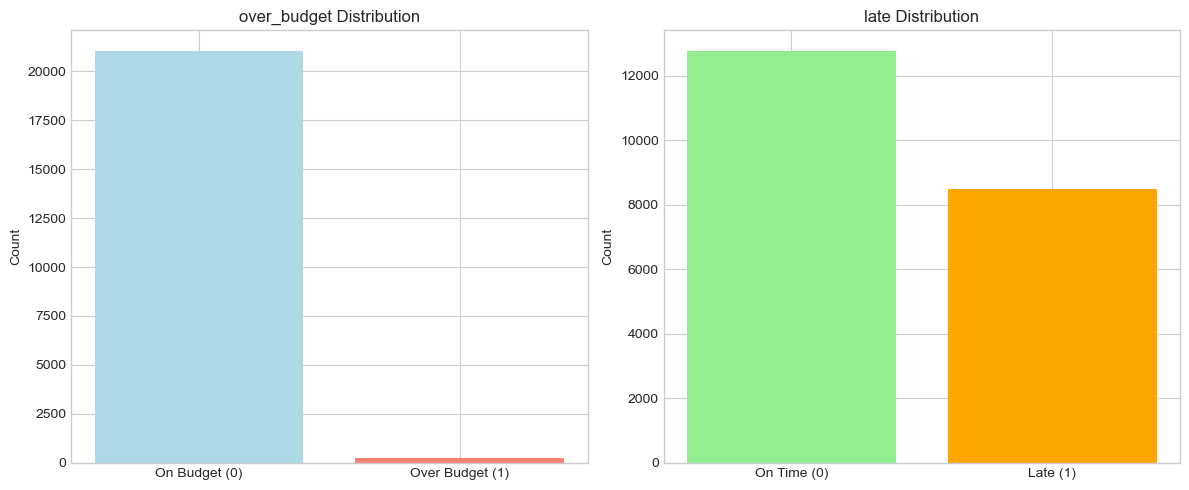

over_budget: 225 positive (1.06%)
late: 8,496 positive (39.95%)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, target, colors, labels in [
    (axes[0], 'over_budget', ['lightblue','salmon'], ['On Budget (0)','Over Budget (1)']),
    (axes[1], 'late', ['lightgreen','orange'], ['On Time (0)','Late (1)'])]:
    counts = labeled_df[target].value_counts().sort_index()
    ax.bar(labels, counts.values, color=colors)
    ax.set_title(f'{target} Distribution')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_FOLDER, 'class_balance.png'), dpi=300, bbox_inches='tight')
plt.show()
for t in ['over_budget','late']:
    pos = labeled_df[t].sum()
    print(f'{t}: {pos:,} positive ({pos/len(labeled_df)*100:.2f}%)')

### 7.2 Cost Growth Distribution

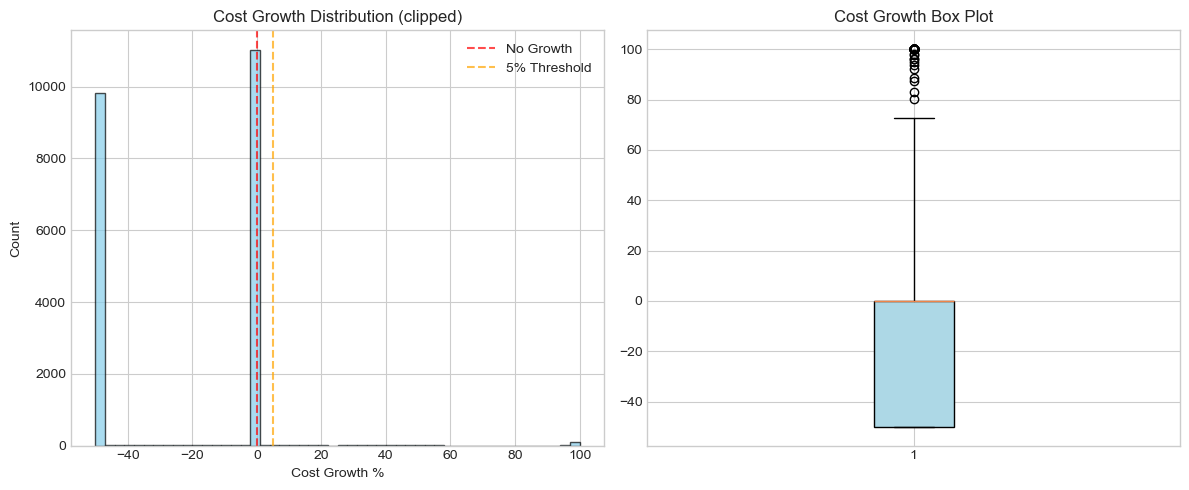

count    2.126700e+04
mean     4.088421e+03
std      5.904739e+05
min     -3.720300e+03
25%     -1.000000e+02
50%      0.000000e+00
75%      0.000000e+00
max      8.609350e+07
Name: cost_growth_pct, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cg = labeled_df['cost_growth_pct'].clip(-50, 100)
axes[0].hist(cg, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].axvline(0, color='red', ls='--', alpha=0.7, label='No Growth')
axes[0].axvline(5, color='orange', ls='--', alpha=0.7, label='5% Threshold')
axes[0].set_xlabel('Cost Growth %'); axes[0].set_ylabel('Count')
axes[0].set_title('Cost Growth Distribution (clipped)'); axes[0].legend()
axes[1].boxplot(cg, vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Cost Growth Box Plot')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_FOLDER, 'cost_growth_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()
print(labeled_df['cost_growth_pct'].describe())

### 7.3 Schedule Delay Distribution

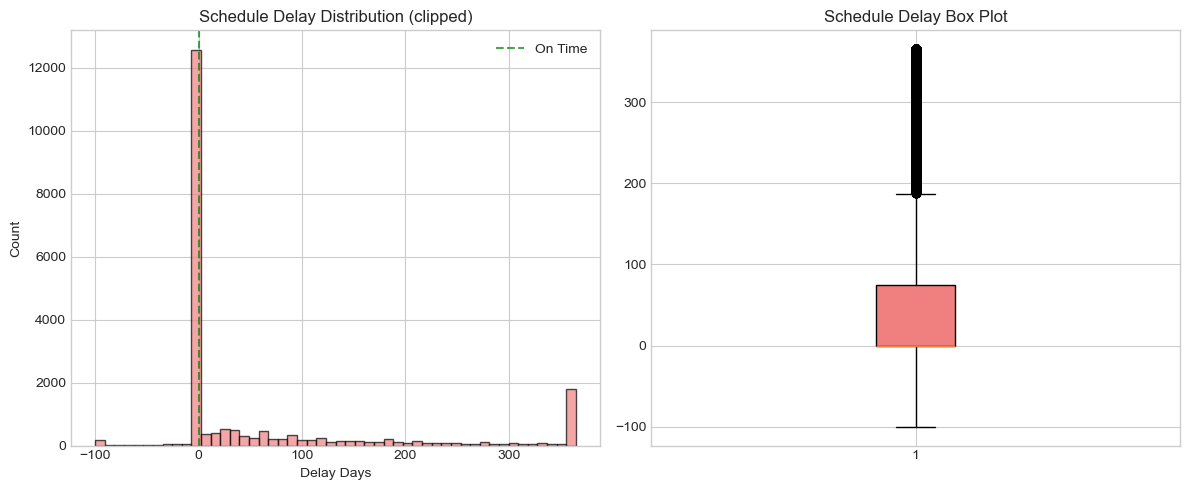

count    21267.000000
mean        98.748013
std        291.851316
min      -3652.000000
25%          0.000000
50%          0.000000
75%         75.000000
max       5987.000000
Name: delay_days, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
dd = labeled_df['delay_days'].clip(-100, 365)
axes[0].hist(dd, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[0].axvline(0, color='green', ls='--', alpha=0.7, label='On Time')
axes[0].set_xlabel('Delay Days'); axes[0].set_ylabel('Count')
axes[0].set_title('Schedule Delay Distribution (clipped)'); axes[0].legend()
axes[1].boxplot(dd, vert=True, patch_artist=True, boxprops=dict(facecolor='lightcoral'))
axes[1].set_title('Schedule Delay Box Plot')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_FOLDER, 'delay_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()
print(labeled_df['delay_days'].describe())

### 7.4 Description Text Quality

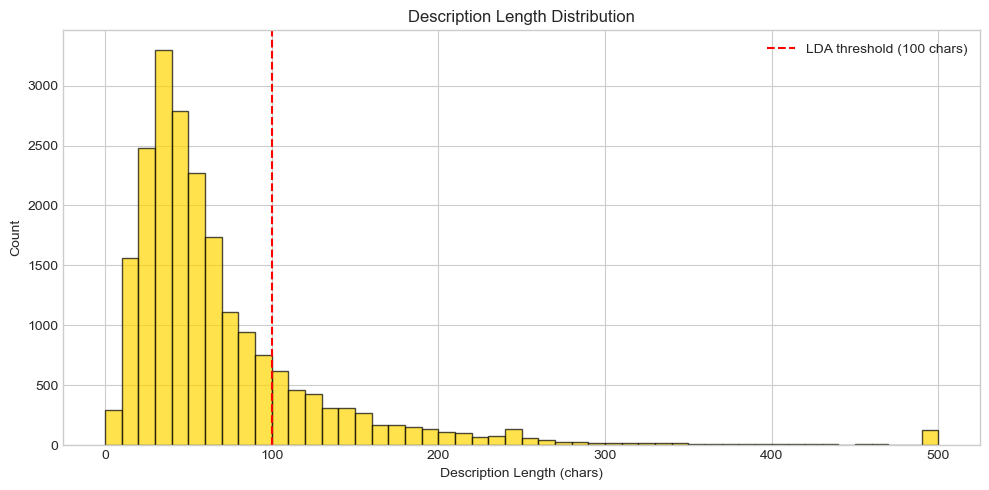

Track A (LDA, >=100 chars): 4,039 contracts
Track B (TF-IDF, all): 21,267 contracts


In [12]:
desc_len = labeled_df['description'].str.len().fillna(0)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(desc_len.clip(upper=500), bins=50, alpha=0.7, color='gold', edgecolor='black')
ax.axvline(MIN_DESCRIPTION_LENGTH, color='red', ls='--', label=f'LDA threshold ({MIN_DESCRIPTION_LENGTH} chars)')
ax.set_xlabel('Description Length (chars)'); ax.set_ylabel('Count')
ax.set_title('Description Length Distribution'); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_FOLDER, 'description_length_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()
long = (desc_len >= MIN_DESCRIPTION_LENGTH).sum()
print(f'Track A (LDA, >={MIN_DESCRIPTION_LENGTH} chars): {long:,} contracts')
print(f'Track B (TF-IDF, all): {len(labeled_df):,} contracts')

### 7.5 Overrun Rates by Category

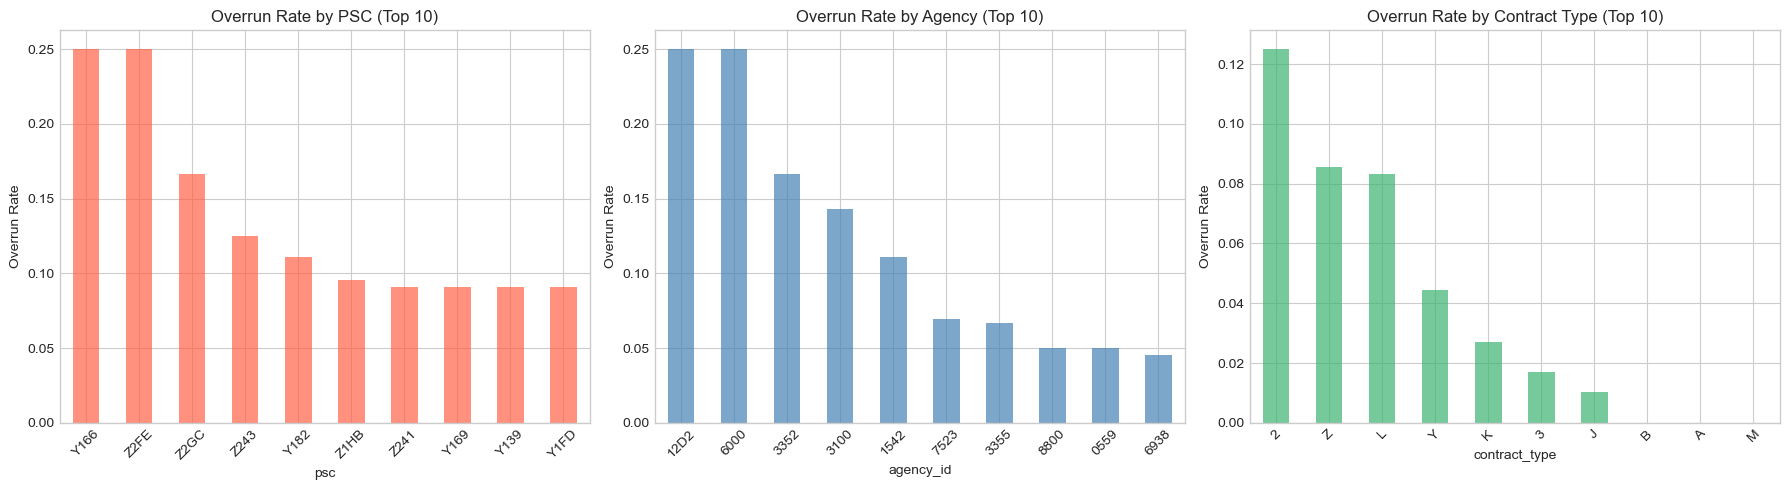

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, title, color in [
    (axes[0], 'psc', 'PSC', 'tomato'),
    (axes[1], 'agency_id', 'Agency', 'steelblue'),
    (axes[2], 'contract_type', 'Contract Type', 'mediumseagreen')]:
    rates = labeled_df.groupby(col)['over_budget'].mean().sort_values(ascending=False).head(10)
    rates.plot.bar(ax=ax, color=color, alpha=0.7)
    ax.set_title(f'Overrun Rate by {title} (Top 10)')
    ax.set_ylabel('Overrun Rate'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_FOLDER, 'overrun_rates_by_category.png'), dpi=300, bbox_inches='tight')
plt.show()

### 7.6 Correlation Heatmap

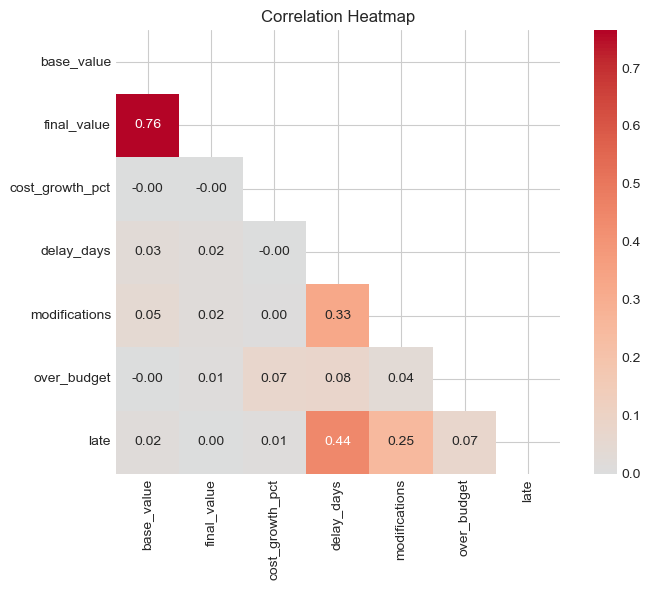

In [14]:
numeric_cols = ['base_value', 'final_value', 'cost_growth_pct', 'delay_days',
                'modifications', 'over_budget', 'late']
corr_df = labeled_df[numeric_cols].apply(pd.to_numeric, errors='coerce')
corr_matrix = corr_df.corr()
plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_FOLDER, 'correlation_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

## 8. Text Preprocessing
Two-track NLP approach:
- **Track A (LDA)**: long descriptions (≥100 chars) with spaCy lemmatization
- **Track B (TF-IDF)**: all descriptions with simple tokenization

In [15]:
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Load spaCy model, installing it automatically if missing
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    from spacy.cli import download as spacy_download
    spacy_download('en_core_web_sm')
    nlp = spacy.load('en_core_web_sm')

print('NLP libraries ready')

NLP libraries ready


In [16]:
from nltk.corpus import stopwords
contract_stopwords = {'contract','shall','will','government','federal','agency',
                      'provide','services','service','support','work','period','require'}
all_stopwords = set(stopwords.words('english')).union(contract_stopwords)

track_a_mask = labeled_df['description'].str.len() >= MIN_DESCRIPTION_LENGTH
track_a_df = labeled_df[track_a_mask].copy()
track_b_df = labeled_df.copy()
print(f'Track A (LDA): {len(track_a_df):,} contracts')
print(f'Track B (TF-IDF): {len(track_b_df):,} contracts')

tqdm.pandas()
track_a_df['clean_description'] = track_a_df['description'].progress_apply(clean_text)
track_b_df['tfidf_text'] = track_b_df['description'].progress_apply(tfidf_tokenize)
print('✅ Text preprocessing complete')

Track A (LDA): 4,039 contracts
Track B (TF-IDF): 21,267 contracts


100%|██████████| 21267/21267 [00:00<00:00, 134516.43it/s]

✅ Text preprocessing complete


## 9. Topic Modeling (LDA) and TF-IDF Feature Extraction

labeled_df shape: (21267, 16)
description exists: True
non-empty descriptions: 21166
max description length: 2580
Track A (LDA): 4,039 contracts
Track B (TF-IDF): 21,267 contracts


100%|██████████| 21267/21267 [00:00<00:00, 114748.72it/s]


✅ Text preprocessing complete
Non-empty cleaned docs for LDA: 4039
Dictionary size before filtering: 9,392
Dictionary size after filtering: 9,392
Corpus size after removing empty docs: 4,039

Coherence search over topic counts:
  topics=10: coherence=0.3863
  topics=15: coherence=0.3935
  topics=20: coherence=0.3908
  topics=25: coherence=0.4116
  topics=30: coherence=0.4162

Best topic count by c_v coherence: 30
LDA_NUM_TOPICS set to: 30


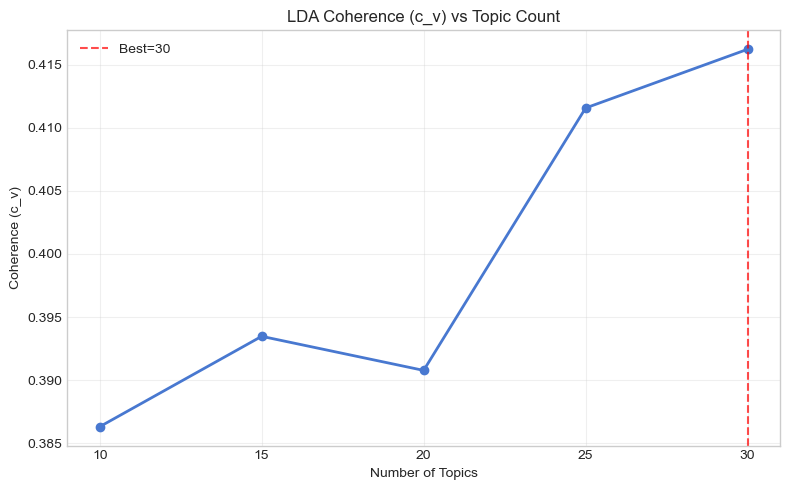

✅ LDA model selected and trained
Topic features shape: (4039, 30)

Top words per topic:
Topic 0: lake, brook, upgrade, area, construction, idiq, matoc, operation, located, minimum
Topic 1: construction, facility, design, north, building, army, center, build, price, storage
Topic 2: hangar, consists, project, unit, space, ground, alteration, throughout, maintenance, made
Topic 3: igf, located, labor, equipment, building, pads, street, supervision, west, contractor
Topic 4: order, task, award, landing, multiple, district, indefinite, design, build, construction
Topic 5: center, building, room, renovation, construction, build, secure, automation, epoxy, bird
Topic 6: mexico, new, control, white, projects, ana, mill, tower, cooling, courthouse
Topic 7: dam, road, fund, project, concrete, asphalt, feet, paving, associated, west
Topic 8: strict, facilities, maintenance, repair, facility, housing, general, family, five, columbus
Topic 9: igf, fire, building, install, water, pump, vault, four,

In [17]:
# -------------------------------------------------
# Downloads / setup
# -------------------------------------------------
nltk.download('stopwords', quiet=True)

# -------------------------------------------------
# Config / fallbacks
# -------------------------------------------------
if 'MIN_DESCRIPTION_LENGTH' not in globals():
    MIN_DESCRIPTION_LENGTH = 1

if 'LDA_NUM_TOPICS' not in globals():
    LDA_NUM_TOPICS = 5

if 'LDA_PASSES' not in globals():
    LDA_PASSES = 10

if 'RANDOM_STATE' not in globals():
    RANDOM_STATE = 42

if 'BASE_DIR' not in globals():
    cwd = Path.cwd()
    candidate_base_dirs = [
        cwd,
        cwd / 'IS392-Final' / 'IS392',
        cwd / 'IS392',
        Path(r'C:/Users/sarme/IS392-Final/IS392'),
    ]

    def _has_project_markers(path_obj):
        return (path_obj / 'step3_code_review.ipynb').exists() and (path_obj / 'data').exists()

    BASE_DIR = next(
        (str(p.resolve()) for p in candidate_base_dirs if _has_project_markers(p)),
        str((cwd / 'IS392-Final' / 'IS392').resolve()),
    )

if 'FIGURES_FOLDER' not in globals():
    FIGURES_FOLDER = os.path.join(BASE_DIR, 'figures')
os.makedirs(FIGURES_FOLDER, exist_ok=True)

# -------------------------------------------------
# Validate / load labeled_df
# -------------------------------------------------
if 'labeled_df' not in globals():
    candidate_labeled_files = []
    if 'FINAL_OUTPUT' in globals():
        candidate_labeled_files.append(FINAL_OUTPUT)
    candidate_labeled_files.append(os.path.join(BASE_DIR, 'data', 'processed', 'labeled_contracts.parquet'))

    loaded = False
    for path in candidate_labeled_files:
        if path and os.path.exists(path):
            labeled_df = pd.read_parquet(path)
            print(f"Loaded labeled_df from: {path}")
            loaded = True
            break

    if not loaded:
        raise NameError(
            "labeled_df is not defined and no saved labeled parquet was found. "
            "Run Sections 2-6 first or ensure data/processed/labeled_contracts.parquet exists."
        )

labeled_df = labeled_df.copy()

# -------------------------------------------------
# Ensure description exists
# -------------------------------------------------
if 'description' not in labeled_df.columns:
    print("⚠️ 'description' column missing in labeled_df. Creating empty placeholder column.")
    labeled_df['description'] = ''

# Clean description safely
labeled_df['description'] = labeled_df['description'].fillna('').astype(str).str.strip()

print("labeled_df shape:", labeled_df.shape)
print("description exists:", 'description' in labeled_df.columns)
print("non-empty descriptions:", (labeled_df['description'] != '').sum())
print("max description length:", labeled_df['description'].str.len().max())

# -------------------------------------------------
# Stopwords
# -------------------------------------------------
contract_stopwords = {
    'contract', 'shall', 'will', 'government', 'federal', 'agency',
    'provide', 'services', 'service', 'support', 'work', 'period', 'require'
}
all_stopwords = set(stopwords.words('english')).union(contract_stopwords)

# -------------------------------------------------
# Text cleaning helpers
# -------------------------------------------------
def clean_text(text):
    """Clean text for LDA and return a space-separated token string."""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [tok for tok in tokens if tok not in all_stopwords and len(tok) > 2]
    return ' '.join(tokens)

def tfidf_tokenize(text):
    """Clean text for TF-IDF and return a space-separated token string."""
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    tokens = text.split()
    tokens = [tok for tok in tokens if tok not in all_stopwords]
    return ' '.join(tokens)

# -------------------------------------------------
# Build Track A / Track B
# -------------------------------------------------
track_a_mask = labeled_df['description'].str.len() >= MIN_DESCRIPTION_LENGTH
track_a_df = labeled_df[track_a_mask].copy()
track_b_df = labeled_df.copy()

print(f"Track A (LDA): {len(track_a_df):,} contracts")
print(f"Track B (TF-IDF): {len(track_b_df):,} contracts")

# -------------------------------------------------
# Preprocess text
# -------------------------------------------------
tqdm.pandas()

if len(track_a_df) > 0:
    track_a_df['clean_description'] = track_a_df['description'].progress_apply(clean_text)
else:
    track_a_df['clean_description'] = pd.Series(dtype=str)

track_b_df['tfidf_text'] = track_b_df['description'].progress_apply(tfidf_tokenize)

print("✅ Text preprocessing complete")

# -------------------------------------------------
# LDA topic modeling with coherence-based topic selection
# -------------------------------------------------
track_a_topic_df = pd.DataFrame()
lda_model = None
topic_coherence_scores = []
topic_candidates = [10, 15, 20, 25, 30]

if len(track_a_df) == 0:
    print("⚠️ No rows passed the description length filter. Skipping LDA.")
else:
    # Keep only non-empty cleaned docs
    track_a_df['clean_description'] = track_a_df['clean_description'].fillna('').astype(str).str.strip()
    lda_input_df = track_a_df[track_a_df['clean_description'] != ''].copy()

    print("Non-empty cleaned docs for LDA:", len(lda_input_df))

    if len(lda_input_df) == 0:
        print("⚠️ All cleaned descriptions are empty. Skipping LDA.")
    else:
        track_a_docs = [doc.split() for doc in lda_input_df['clean_description']]

        dictionary = Dictionary(track_a_docs)
        print(f"Dictionary size before filtering: {len(dictionary):,}")

        # Less aggressive filtering so everything doesn't get removed
        dictionary.filter_extremes(no_below=1, no_above=0.9)
        print(f"Dictionary size after filtering: {len(dictionary):,}")

        if len(dictionary) < 2:
            print("⚠️ Dictionary is too small after filtering (<2 terms). Skipping LDA.")
        else:
            corpus = [dictionary.doc2bow(doc) for doc in track_a_docs]

            # Remove empty bow docs
            nonempty_rows = []
            nonempty_docs = []
            nonempty_corpus = []

            for idx, doc_tokens, bow in zip(lda_input_df.index, track_a_docs, corpus):
                if len(bow) > 0:
                    nonempty_rows.append(idx)
                    nonempty_docs.append(doc_tokens)
                    nonempty_corpus.append(bow)

            print(f"Corpus size after removing empty docs: {len(nonempty_corpus):,}")

            if len(nonempty_corpus) == 0:
                print("⚠️ Corpus is empty after bag-of-words conversion. Skipping LDA.")
            else:
                valid_topic_candidates = [k for k in topic_candidates if k <= len(dictionary)]
                if not valid_topic_candidates:
                    valid_topic_candidates = [min(10, len(dictionary))]

                candidate_models = {}
                print("\nCoherence search over topic counts:")
                for n_topics in valid_topic_candidates:
                    try:
                        candidate_model = LdaModel(
                            corpus=nonempty_corpus,
                            id2word=dictionary,
                            num_topics=n_topics,
                            passes=LDA_PASSES,
                            random_state=RANDOM_STATE,
                            alpha='auto',
                            eta='auto'
                        )
                        candidate_models[n_topics] = candidate_model

                        coherence_model = CoherenceModel(
                            model=candidate_model,
                            texts=nonempty_docs,
                            dictionary=dictionary,
                            coherence='c_v'
                        )
                        score = coherence_model.get_coherence()
                        topic_coherence_scores.append((n_topics, score))
                        print(f"  topics={n_topics}: coherence={score:.4f}")
                    except Exception as exc:
                        print(f"  topics={n_topics}: failed ({exc})")

                if topic_coherence_scores:
                    best_topic_count = max(topic_coherence_scores, key=lambda x: x[1])[0]
                    LDA_NUM_TOPICS = best_topic_count
                    lda_model = candidate_models[best_topic_count]
                    print(f"\nBest topic count by c_v coherence: {best_topic_count}")
                    print(f"LDA_NUM_TOPICS set to: {LDA_NUM_TOPICS}")

                    # Plot coherence vs topic count
                    topic_x = [k for k, _ in topic_coherence_scores]
                    coherence_y = [v for _, v in topic_coherence_scores]
                    plt.figure(figsize=(8, 5))
                    plt.plot(topic_x, coherence_y, marker='o', linewidth=2)
                    plt.axvline(
                        best_topic_count, color='red', linestyle='--', alpha=0.7,
                        label=f'Best={best_topic_count}'
                    )
                    plt.title('LDA Coherence (c_v) vs Topic Count')
                    plt.xlabel('Number of Topics')
                    plt.ylabel('Coherence (c_v)')
                    plt.xticks(valid_topic_candidates)
                    plt.grid(alpha=0.3)
                    plt.legend()
                    plt.tight_layout()
                    plt.savefig(
                        os.path.join(FIGURES_FOLDER, 'lda_coherence_vs_topics.png'),
                        dpi=300, bbox_inches='tight'
                    )
                    plt.show()

                    print("✅ LDA model selected and trained")

                    # Extract topic proportions
                    topic_cols = [f'topic_{i}' for i in range(LDA_NUM_TOPICS)]
                    topic_vecs = []

                    for doc_bow in nonempty_corpus:
                        dist = lda_model.get_document_topics(doc_bow, minimum_probability=0)
                        topic_vecs.append([p for _, p in dist])

                    track_a_topic_df = pd.DataFrame(
                        topic_vecs,
                        columns=topic_cols,
                        index=nonempty_rows
                    )

                    print(f"Topic features shape: {track_a_topic_df.shape}")

                    # Show top words per topic
                    print("\nTop words per topic:")
                    for i in range(LDA_NUM_TOPICS):
                        words = lda_model.show_topic(i, topn=10)
                        words_str = ', '.join([word for word, _ in words])
                        print(f"Topic {i}: {words_str}")
                else:
                    print("⚠️ No valid LDA model/coherence score could be computed.")

# -------------------------------------------------
# Final previews
# -------------------------------------------------
print("\nTrack A preview:")
preview_a = ['description', 'clean_description']
preview_a = [c for c in preview_a if c in track_a_df.columns]
if preview_a:
    print(track_a_df[preview_a].head())

print("\nTrack B preview:")
preview_b = ['description', 'tfidf_text']
preview_b = [c for c in preview_b if c in track_b_df.columns]
if preview_b:
    print(track_b_df[preview_b].head())

print("\nLDA topic feature preview:")
if not track_a_topic_df.empty:
    print(track_a_topic_df.head())
else:
    print("No topic features created.")

In [18]:
# Track B: TF-IDF
if 'TFIDF_MAX_FEATURES' not in globals():
    TFIDF_MAX_FEATURES = 5000

tfidf_texts = track_b_df['tfidf_text'].fillna('').astype(str)
nonempty_tfidf = tfidf_texts.str.strip() != ''
if nonempty_tfidf.any():
    tfidf_vectorizer = TfidfVectorizer(
        max_features=TFIDF_MAX_FEATURES, min_df=5, max_df=0.5,
        ngram_range=(1, 2), stop_words=list(all_stopwords), lowercase=True
    )
    tfidf_matrix = tfidf_vectorizer.fit_transform(tfidf_texts)
    print(f'TF-IDF shape: {tfidf_matrix.shape}')
    print(f'Avg non-zero features/doc: {tfidf_matrix.nnz / tfidf_matrix.shape[0]:.1f}')
else:
    tfidf_matrix = None
    print('No non-empty TF-IDF documents found; skipping TF-IDF feature generation.')

TF-IDF shape: (21267, 5000)
Avg non-zero features/doc: 8.8


In [19]:
if 'lda_model' in globals() and lda_model is not None:
    print('LDA Topics:')
    for idx, topic in lda_model.print_topics(num_words=8):
        words = [w.split('*')[1].strip('"') for w in topic.split(' + ')]
        print(f'  Topic {idx}: {", ".join(words)}')
else:
    print('LDA model is unavailable; no topics to display.')

LDA Topics:
  Topic 14: log, tas, arra, station, ranger, recovery, call, bpa
  Topic 13: software, automated, option, year, maintenance, items, border, non
  Topic 28: aircraft, suspended, entrance, avenue, door, glass, square, ssa
  Topic 6: mexico, new, control, white, projects, ana, mill, tower
  Topic 29: electrical, replace, project, remove, existing, date, buildings, room
  Topic 2: hangar, consists, project, unit, space, ground, alteration, throughout
  Topic 26: reserve, areas, restoration, full, replace, age, chiller, center
  Topic 0: lake, brook, upgrade, area, construction, idiq, matoc, operation
  Topic 12: tas, office, minor, sewer, canal, update, everett, chicago
  Topic 15: removal, system, tas, install, ntp, plant, access, alarm
  Topic 20: base, air, igf, force, new, kirtland, hvac, repair
  Topic 16: bid, performance, security, days, igf, creek, abatement, calendar
  Topic 1: construction, facility, design, north, building, army, center, build
  Topic 4: order, task,

## 10. Feature Matrix Construction
Four feature configurations:
1. **Structured-only**: contract attributes
2. **TF-IDF-only**: text features
3. **Combined**: structured + TF-IDF
4. **Structured+LDA**: structured + topic proportions

In [20]:
# Prepare structured features with proper NaN handling
struct_cols = ['base_value', 'final_value', 'modifications', 'num_offers']
struct_df = labeled_df[struct_cols].copy()

# Convert num_offers from object to numeric (contains None strings)
struct_df['num_offers'] = pd.to_numeric(struct_df['num_offers'], errors='coerce')

# Fill all missing values
struct_df = struct_df.fillna({
    'base_value': 0,
    'final_value': 0,
    'modifications': 1,
    'num_offers': 1
})

# Safe log transform: use log1p(abs(x)) * sign(x) to handle negatives
struct_df['log_base_value'] = np.sign(struct_df['base_value']) * np.log1p(np.abs(struct_df['base_value']))
struct_df['log_final_value'] = np.sign(struct_df['final_value']) * np.log1p(np.abs(struct_df['final_value']))
struct_df = struct_df.drop(['base_value', 'final_value'], axis=1)

# Replace any remaining inf/NaN with 0
struct_df = struct_df.replace([np.inf, -np.inf], 0).fillna(0)

print(f'Structured features: {struct_df.shape}')
print(f'NaN check: {struct_df.isna().sum().sum()} NaN values remaining')

# Build 4 configurations
if 'tfidf_matrix' in globals() and tfidf_matrix is not None:
    tfidf_dense = pd.DataFrame(
        tfidf_matrix.toarray(),
        columns=[f'tfidf_{i}' for i in range(tfidf_matrix.shape[1])],
        index=labeled_df.index
    )
else:
    tfidf_dense = pd.DataFrame(index=labeled_df.index)
    print('⚠️ TF-IDF matrix unavailable; TF-IDF-based configs will contain only available features.')

X_structured = struct_df
X_tfidf = tfidf_dense
X_combined = pd.concat([struct_df, tfidf_dense], axis=1)

# Structured+LDA: only for contracts with long descriptions
if 'track_a_topic_df' in globals() and not track_a_topic_df.empty:
    common_lda_idx = struct_df.index.intersection(track_a_topic_df.index)
    X_struct_lda = pd.concat([struct_df.loc[common_lda_idx], track_a_topic_df.loc[common_lda_idx]], axis=1)
else:
    common_lda_idx = struct_df.index[:0]
    X_struct_lda = struct_df.loc[common_lda_idx].copy()
    print('⚠️ LDA topic features unavailable; Structured+LDA config is empty.')

y_full = labeled_df['over_budget']
y_lda = labeled_df.loc[common_lda_idx, 'over_budget']

feature_configs = {
    'Structured': (X_structured, y_full),
    'TF-IDF': (X_tfidf, y_full),
    'Combined': (X_combined, y_full),
    'Structured+LDA': (X_struct_lda, y_lda),
}

for name, (X, y) in feature_configs.items():
    pos = int(y.sum()) if len(y) > 0 else 0
    rate = (y.mean() * 100) if len(y) > 0 else 0.0
    print(f'  {name}: X={X.shape}, y positive={pos} ({rate:.2f}%)')

Structured features: (21267, 4)
NaN check: 0 NaN values remaining
  Structured: X=(21267, 4), y positive=225 (1.06%)
  TF-IDF: X=(21267, 5000), y positive=225 (1.06%)
  Combined: X=(21267, 5004), y positive=225 (1.06%)
  Structured+LDA: X=(4039, 34), y positive=40 (0.99%)


## 11. Preliminary Classification
Train Logistic Regression and Random Forest with `class_weight='balanced'` on each feature configuration.

In [21]:
if 'TEST_SIZE' not in globals():
    TEST_SIZE = 0.20

feature_order = list(feature_configs.keys())

# Keep the original experiment outputs in their own dictionaries
over_budget_results = {}
late_results = {}

print('Training classifiers...\n')

for target_name in ['over_budget', 'late']:
    print(f'######## Target: {target_name} ########')
    target_results = {}

    for config_name in feature_order:
        X, _ = feature_configs[config_name]
        y = labeled_df.loc[X.index, target_name]

        print(f'=== {config_name} ===')
        if len(X) == 0 or y.nunique() < 2:
            print(f'  Skipping {config_name}: insufficient rows or only one class present for {target_name}.')
            continue

        try:
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
            )
        except ValueError as exc:
            print(f'  Skipping {config_name}: train/test split failed ({exc})')
            continue

        config_results = {}
        for model_name, model in [
            ('Logistic Regression', LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000)),
            ('Random Forest', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_estimators=100))
        ]:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            y_proba = model.predict_proba(X_test)[:, 1]
            f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
            auc = roc_auc_score(y_test, y_proba)
            print(f'  {model_name}: F1={f1:.3f}, AUC={auc:.3f}')
            config_results[model_name] = {
                'y_test': y_test,
                'y_proba': y_proba,
                'f1': f1,
                'auc': auc
            }

        target_results[config_name] = config_results
        print()

    if target_name == 'over_budget':
        over_budget_results = target_results
    else:
        late_results = target_results

    print()

# Backward-compatible combined container for downstream cells
results = {
    'over_budget': over_budget_results,
    'late': late_results,
}

print('✅ Classification complete')

Training classifiers...

######## Target: over_budget ########
=== Structured ===
  Logistic Regression: F1=0.915, AUC=0.999
  Random Forest: F1=0.734, AUC=0.999

=== TF-IDF ===
  Logistic Regression: F1=0.038, AUC=0.563
  Random Forest: F1=0.033, AUC=0.507

=== Combined ===
  Logistic Regression: F1=0.809, AUC=0.997
  Random Forest: F1=0.085, AUC=0.970

=== Structured+LDA ===
  Logistic Regression: F1=0.800, AUC=0.995
  Random Forest: F1=0.000, AUC=0.984


######## Target: late ########
=== Structured ===
  Logistic Regression: F1=0.748, AUC=0.838
  Random Forest: F1=0.711, AUC=0.830

=== TF-IDF ===
  Logistic Regression: F1=0.519, AUC=0.618
  Random Forest: F1=0.431, AUC=0.602

=== Combined ===
  Logistic Regression: F1=0.743, AUC=0.851
  Random Forest: F1=0.779, AUC=0.870

=== Structured+LDA ===
  Logistic Regression: F1=0.736, AUC=0.849
  Random Forest: F1=0.789, AUC=0.873


✅ Classification complete


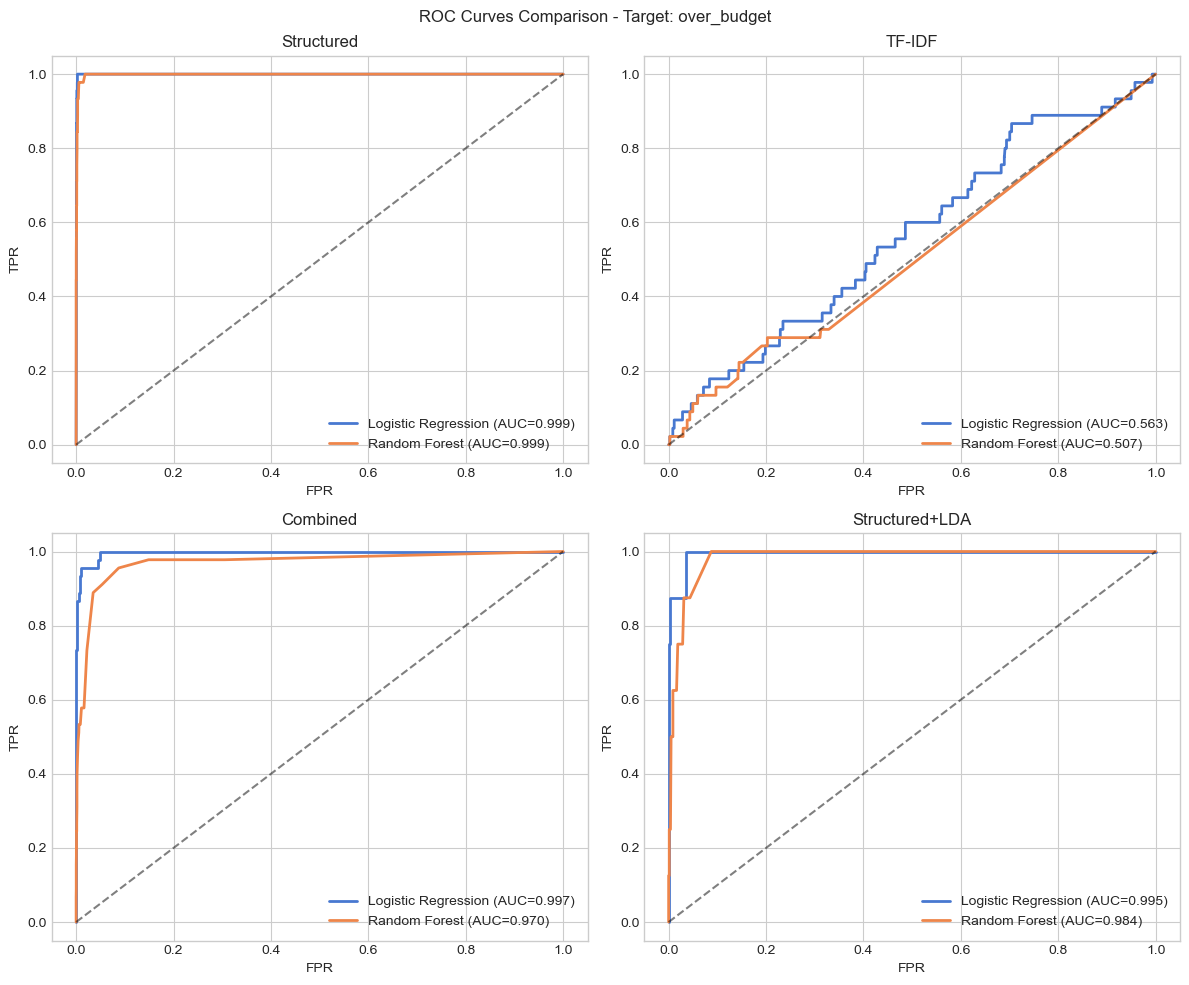

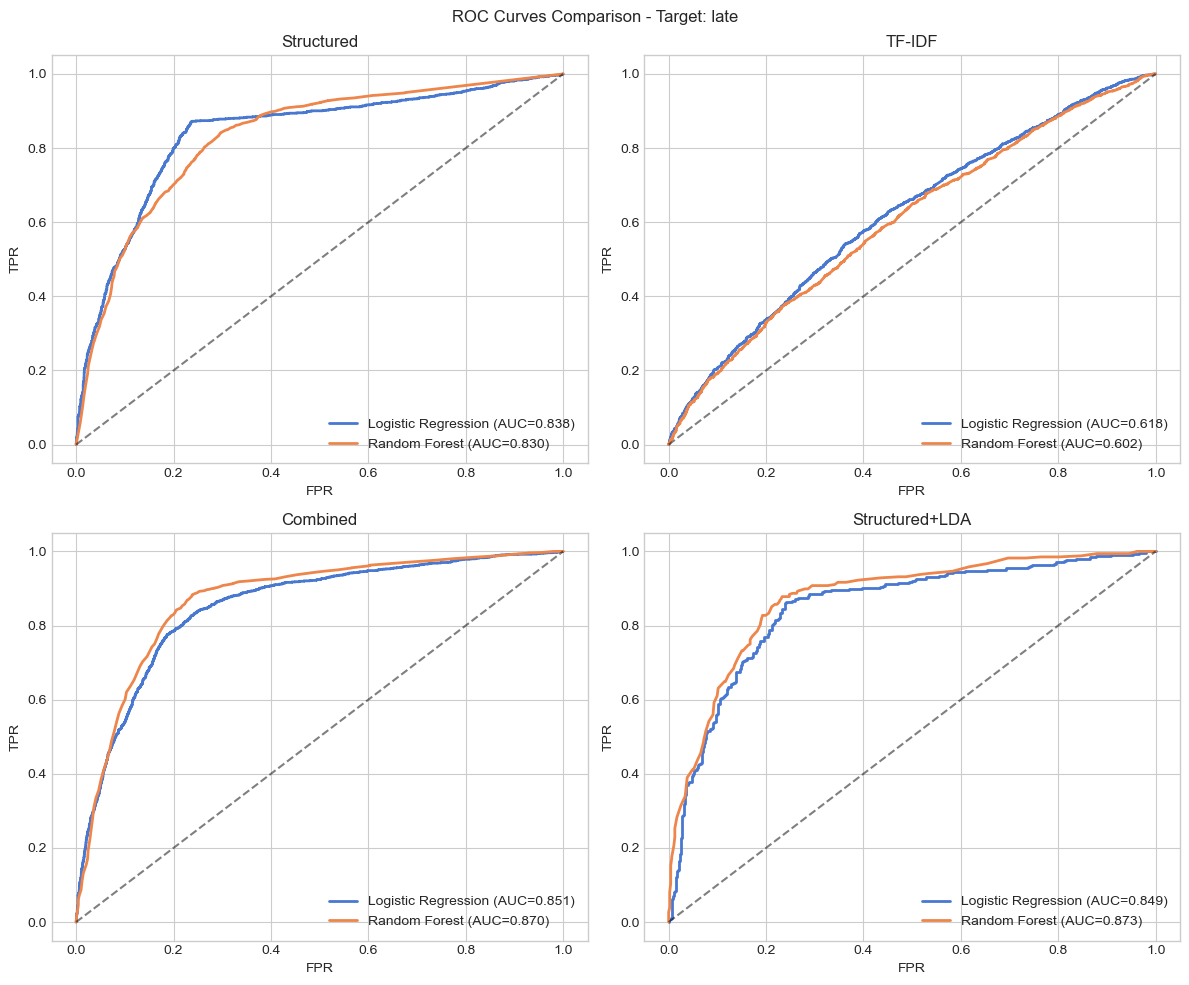

In [22]:
plot_targets = [
    ('over_budget', over_budget_results),
    ('late', late_results),
]

for target_name, target_results in plot_targets:
    if not target_results:
        print(f'No results to plot for target={target_name}')
        continue

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    for ax, config_name in zip(axes.ravel(), feature_order):
        if config_name not in target_results:
            ax.set_axis_off()
            ax.set_title(f'{config_name} (not available)')
            continue

        config_results = target_results[config_name]
        for model_name, r in config_results.items():
            fpr, tpr, _ = roc_curve(r['y_test'], r['y_proba'])
            ax.plot(fpr, tpr, label=f"{model_name} (AUC={r['auc']:.3f})", lw=2)

        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.set_title(config_name)
        ax.legend(loc='lower right')

    plt.suptitle(f'ROC Curves Comparison - Target: {target_name}')
    plt.tight_layout()
    output_name = f'roc_curves_comparison_{target_name}.png'
    plt.savefig(os.path.join(FIGURES_FOLDER, output_name), dpi=300, bbox_inches='tight')
    plt.show()

In [23]:
summary_targets = [
    ('over_budget', over_budget_results),
    ('late', late_results),
]

for target_name, target_results in summary_targets:
    print(f'Performance Summary ({target_name}):')
    print(f'{"Config":<20} {"LR F1":>8} {"LR AUC":>8} {"RF F1":>8} {"RF AUC":>8}')
    print('-' * 56)

    for config_name in feature_order:
        if config_name not in target_results:
            print(f'{config_name:<20} {"N/A":>8} {"N/A":>8} {"N/A":>8} {"N/A":>8}')
            continue

        cr = target_results[config_name]
        lr = cr['Logistic Regression']
        rf = cr['Random Forest']
        print(f'{config_name:<20} {lr["f1"]:8.3f} {lr["auc"]:8.3f} {rf["f1"]:8.3f} {rf["auc"]:8.3f}')

    print()

Performance Summary (over_budget):
Config                  LR F1   LR AUC    RF F1   RF AUC
--------------------------------------------------------
Structured              0.915    0.999    0.734    0.999
TF-IDF                  0.038    0.563    0.033    0.507
Combined                0.809    0.997    0.085    0.970
Structured+LDA          0.800    0.995    0.000    0.984

Performance Summary (late):
Config                  LR F1   LR AUC    RF F1   RF AUC
--------------------------------------------------------
Structured              0.748    0.838    0.711    0.830
TF-IDF                  0.519    0.618    0.431    0.602
Combined                0.743    0.851    0.779    0.870
Structured+LDA          0.736    0.849    0.789    0.873



## 12. Hyperparameter Tuning with RandomizedSearchCV

Use `RandomizedSearchCV` with stratified k-fold cross-validation to optimize hyperparameters for Logistic Regression and Random Forest on the combined feature set targeting the `over_budget` classification task.

In [24]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Define StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 70)
print("HYPERPARAMETER TUNING WITH RANDOMIZED SEARCH")
print("=" * 70)
print(f"Feature matrix shape: {X_train.shape}")
print(f"Target distribution - Class 0: {(y_train == 0).sum()}, Class 1: {(y_train == 1).sum()}")
print()

# ============================================================================
# LOGISTIC REGRESSION TUNING
# ============================================================================
print("=" * 70)
print("1. LOGISTIC REGRESSION HYPERPARAMETER TUNING")
print("=" * 70)

# Define parameter distributions for Logistic Regression
lr_param_dist = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [500, 1000]
}

# Initialize RandomizedSearchCV for Logistic Regression
lr_random_search = RandomizedSearchCV(
    LogisticRegression(random_state=42, class_weight='balanced'),
    param_distributions=lr_param_dist,
    n_iter=20,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit on training data
print("\nFitting Logistic Regression with RandomizedSearchCV...")
lr_random_search.fit(X_train, y_train)

print(f"\nBest Parameters for Logistic Regression:")
print(f"  {lr_random_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {lr_random_search.best_score_:.4f}")

# ============================================================================
# RANDOM FOREST TUNING
# ============================================================================
print()
print("=" * 70)
print("2. RANDOM FOREST HYPERPARAMETER TUNING")
print("=" * 70)

# Define parameter distributions for Random Forest
rf_param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample']
}

# Initialize RandomizedSearchCV for Random Forest
rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit on training data
print("\nFitting Random Forest with RandomizedSearchCV...")
rf_random_search.fit(X_train, y_train)

print(f"\nBest Parameters for Random Forest:")
print(f"  {rf_random_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {rf_random_search.best_score_:.4f}")

# ============================================================================
# SUMMARY COMPARISON
# ============================================================================
print()
print("=" * 70)
print("TUNING SUMMARY")
print("=" * 70)
print(f"{'Model':<25} {'Best F1 Score':<20} {'Best Params':<25}")
print("-" * 70)
print(f"{'Logistic Regression':<25} {lr_random_search.best_score_:<20.4f} C={lr_random_search.best_params_['C']}, solver={lr_random_search.best_params_['solver']}")
print(f"{'Random Forest':<25} {rf_random_search.best_score_:<20.4f} n_est={rf_random_search.best_params_['n_estimators']}, max_depth={rf_random_search.best_params_['max_depth']}")
print("=" * 70)

HYPERPARAMETER TUNING WITH RANDOMIZED SEARCH
Feature matrix shape: (3231, 34)
Target distribution - Class 0: 1889, Class 1: 1342

1. LOGISTIC REGRESSION HYPERPARAMETER TUNING

Fitting Logistic Regression with RandomizedSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters for Logistic Regression:
  {'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 1000, 'C': 0.1}
Best Cross-Validation F1 Score: 0.7289

2. RANDOM FOREST HYPERPARAMETER TUNING

Fitting Random Forest with RandomizedSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters for Random Forest:
  {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10, 'class_weight': 'balanced'}
Best Cross-Validation F1 Score: 0.7826

TUNING SUMMARY
Model                     Best F1 Score        Best Params              
----------------------------------------------------------------------
Logistic Regression       0.

## 13. Handling Class Imbalance (SMOTE / ADASYN)

In [25]:
# Class imbalance handling on over_budget using Combined features
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

if 'TEST_SIZE' not in globals():
    TEST_SIZE = 0.20

if 'RANDOM_STATE' not in globals():
    RANDOM_STATE = 42

if 'X_combined' in globals():
    X_imb = X_combined.copy()
elif 'feature_configs' in globals() and 'Combined' in feature_configs:
    X_imb, _ = feature_configs['Combined']
    X_imb = X_imb.copy()
else:
    raise NameError("X_combined is unavailable. Run Feature Matrix Construction first.")

if 'labeled_df' not in globals() or 'over_budget' not in labeled_df.columns:
    raise NameError("labeled_df['over_budget'] is unavailable. Run label construction first.")

y_imb = labeled_df.loc[X_imb.index, 'over_budget'].astype(int)

# Print class distribution before oversampling
print('Class distribution before oversampling (full target):')
print(y_imb.value_counts().sort_index())
print()

# Split first; oversampling must happen only on training data
X_train, X_test, y_train, y_test = train_test_split(
    X_imb, y_imb,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_imb
)

print('Class distribution before oversampling (training split):')
print(y_train.value_counts().sort_index())
print()

# Handle extreme imbalance safely by adapting neighbors to minority size
minority_count = int(y_train.value_counts().min())
if minority_count < 2:
    raise ValueError(
        'Minority class has fewer than 2 samples in training data; cannot apply SMOTE/ADASYN safely.'
    )

adaptive_neighbors = max(1, min(3, minority_count - 1))
print(f'Using k_neighbors/n_neighbors = {adaptive_neighbors}')
print()

# Logistic Regression + SMOTE
smote_lr_pipeline = ImbPipeline(steps=[
    ('sampler', SMOTE(k_neighbors=adaptive_neighbors, random_state=RANDOM_STATE)),
    ('model', LogisticRegression(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

smote_lr_pipeline.fit(X_train, y_train)
smote_pred = smote_lr_pipeline.predict(X_test)
smote_proba = smote_lr_pipeline.predict_proba(X_test)[:, 1]

smote_f1 = f1_score(y_test, smote_pred, pos_label=1, zero_division=0)
smote_auc = roc_auc_score(y_test, smote_proba)

print('SMOTE + Logistic Regression')
print(f'F1: {smote_f1:.4f}')
print(f'ROC AUC: {smote_auc:.4f}')
print('Classification Report:')
print(classification_report(y_test, smote_pred, digits=4, zero_division=0))

# Logistic Regression + ADASYN
adasyn_lr_pipeline = ImbPipeline(steps=[
    ('sampler', ADASYN(n_neighbors=adaptive_neighbors, random_state=RANDOM_STATE)),
    ('model', LogisticRegression(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

adasyn_lr_pipeline.fit(X_train, y_train)
adasyn_pred = adasyn_lr_pipeline.predict(X_test)
adasyn_proba = adasyn_lr_pipeline.predict_proba(X_test)[:, 1]

adasyn_f1 = f1_score(y_test, adasyn_pred, pos_label=1, zero_division=0)
adasyn_auc = roc_auc_score(y_test, adasyn_proba)

print('ADASYN + Logistic Regression')
print(f'F1: {adasyn_f1:.4f}')
print(f'ROC AUC: {adasyn_auc:.4f}')
print('Classification Report:')
print(classification_report(y_test, adasyn_pred, digits=4, zero_division=0))

Class distribution before oversampling (full target):
over_budget
0    21042
1      225
Name: count, dtype: int64

Class distribution before oversampling (training split):
over_budget
0    16833
1      180
Name: count, dtype: int64

Using k_neighbors/n_neighbors = 3

SMOTE + Logistic Regression
F1: 0.8571
ROC AUC: 0.9968
Classification Report:
              precision    recall  f1-score   support

           0     0.9979    0.9993    0.9986      4209
           1     0.9231    0.8000    0.8571        45

    accuracy                         0.9972      4254
   macro avg     0.9605    0.8996    0.9279      4254
weighted avg     0.9971    0.9972    0.9971      4254

ADASYN + Logistic Regression
F1: 0.8315
ROC AUC: 0.9966
Classification Report:
              precision    recall  f1-score   support

           0     0.9981    0.9983    0.9982      4209
           1     0.8409    0.8222    0.8315        45

    accuracy                         0.9965      4254
   macro avg     0.9195    0.9

## 14. Advanced Models (XGBoost / LightGBM)

In [26]:
# Advanced ensemble models for over_budget on Combined features
if 'TEST_SIZE' not in globals():
    TEST_SIZE = 0.20

if 'RANDOM_STATE' not in globals():
    RANDOM_STATE = 42

if 'X_combined' in globals():
    X_adv = X_combined.copy()
elif 'feature_configs' in globals() and 'Combined' in feature_configs:
    X_adv, _ = feature_configs['Combined']
    X_adv = X_adv.copy()
else:
    raise NameError("X_combined is unavailable. Run Feature Matrix Construction first.")

if 'labeled_df' not in globals() or 'over_budget' not in labeled_df.columns:
    raise NameError("labeled_df['over_budget'] is unavailable. Run label construction first.")

y_adv = labeled_df.loc[X_adv.index, 'over_budget'].astype(int)

# Keep the split stratified due to severe class imbalance
X_train, X_test, y_train, y_test = train_test_split(
    X_adv, y_adv, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_adv
)

neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
if pos == 0:
    raise ValueError('No positive samples in y_train; cannot fit advanced models.')

scale_pos_weight = neg / pos
print(f'Train class counts -> negative: {neg}, positive: {pos}, scale_pos_weight: {scale_pos_weight:.2f}')
print()

advanced_results = {}

# -------------------------
# XGBoost (if installed)
# -------------------------
try:
    from xgboost import XGBClassifier

    xgb_model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1
    )

    xgb_model.fit(X_train, y_train)
    xgb_pred = xgb_model.predict(X_test)
    xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

    xgb_f1 = f1_score(y_test, xgb_pred, pos_label=1, zero_division=0)
    xgb_auc = roc_auc_score(y_test, xgb_proba)

    advanced_results['XGBoost'] = {'f1': xgb_f1, 'auc': xgb_auc}

    print('XGBoost Results')
    print(f'F1: {xgb_f1:.4f}')
    print(f'ROC AUC: {xgb_auc:.4f}')
    print('Classification Report:')
    print(classification_report(y_test, xgb_pred, digits=4, zero_division=0))
    print()
except ImportError:
    print('XGBoost is not installed in this kernel; skipping XGBoost experiment.')
    print()

# ---------------------------
# LightGBM (if installed)
# ---------------------------
try:
    from lightgbm import LGBMClassifier

    lgbm_model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=RANDOM_STATE,
        class_weight='balanced',
        n_jobs=-1
    )

    lgbm_model.fit(X_train, y_train)
    lgbm_pred = lgbm_model.predict(X_test)
    lgbm_proba = lgbm_model.predict_proba(X_test)[:, 1]

    lgbm_f1 = f1_score(y_test, lgbm_pred, pos_label=1, zero_division=0)
    lgbm_auc = roc_auc_score(y_test, lgbm_proba)

    advanced_results['LightGBM'] = {'f1': lgbm_f1, 'auc': lgbm_auc}

    print('LightGBM Results')
    print(f'F1: {lgbm_f1:.4f}')
    print(f'ROC AUC: {lgbm_auc:.4f}')
    print('Classification Report:')
    print(classification_report(y_test, lgbm_pred, digits=4, zero_division=0))
    print()
except ImportError:
    print('LightGBM is not installed in this kernel; skipping LightGBM experiment.')
    print()

if not advanced_results:
    print('No advanced model ran because neither xgboost nor lightgbm is available in the current kernel.')

Train class counts -> negative: 16833, positive: 180, scale_pos_weight: 93.52

XGBoost Results
F1: 0.8041
ROC AUC: 0.9989
Classification Report:
              precision    recall  f1-score   support

           0     0.9986    0.9969    0.9977      4209
           1     0.7500    0.8667    0.8041        45

    accuracy                         0.9955      4254
   macro avg     0.8743    0.9318    0.9009      4254
weighted avg     0.9959    0.9955    0.9957      4254


[LightGBM] [Info] Number of positive: 180, number of negative: 16833
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.029568 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 34205
[LightGBM] [Info] Number of data points in the train set: 17013, number of used features: 1389
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM Results
F1: 0.7955
ROC AU

## 15. Model Interpretation (SHAP)

Use SHAP (SHapley Additive exPlanations) to explain the predictions of the
best tree-based model (XGBoost) trained in Section 13.  
A **beeswarm** (summary) plot shows which features push predictions toward
`over_budget = 1` (red) or `0` (blue) and by how much.  
A **bar** plot shows mean absolute SHAP value (global feature importance).

In [27]:
# SHAP analysis for the best tree-based model (XGBoost preferred over LightGBM)
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

try:
    import shap
    shap_available = True
except ImportError:
    shap_available = False
    print('shap is not installed. Run: pip install shap')

if not shap_available:
    print('Skipping Section 14 — install shap and re-run this cell.')
else:
    # 1. Locate best trained model and test split from Section 13
    if 'xgb_model' in globals():
        best_model = xgb_model
        best_model_name = 'XGBoost'
    elif 'lgbm_model' in globals():
        best_model = lgbm_model
        best_model_name = 'LightGBM'
    else:
        raise NameError('No trained model found. Run Section 13 first.')

    if 'X_test' not in globals() or 'y_test' not in globals():
        raise NameError('X_test / y_test not found. Run Section 13 first.')

    print(f'Model: {best_model_name}')
    print(f'X_test shape: {X_test.shape}')

    # 2. Sub-sample for speed (SHAP on dense data can be slow)
    SHAP_SAMPLE = 300
    np.random.seed(42)
    if X_test.shape[0] > SHAP_SAMPLE:
        sample_idx = np.random.choice(X_test.shape[0], size=SHAP_SAMPLE, replace=False)
        X_shap_df = X_test.iloc[sample_idx].copy()
    else:
        X_shap_df = X_test.copy()

    # Save original column names
    original_columns = list(X_shap_df.columns)
    
    # Convert to numpy float32 for best compatibility
    X_shap = np.asarray(X_shap_df.values, dtype=np.float32)

    print(f'Computing SHAP values on {len(X_shap)} samples using KernelExplainer...')

    # 3. Compute SHAP values using KernelExplainer (compatible with XGBoost 2.0+)
    def model_predict(X):
        '''Wrapper for model prediction'''
        if len(X.shape) == 1:
            X = X.reshape(1, -1)
        return best_model.predict_proba(X)[:, 1]  # Use probability for binary classification
    
    # Use first 50 samples as background for efficiency
    background = X_shap[:min(50, len(X_shap))]
    
    explainer = shap.KernelExplainer(model_predict, background)
    print('  Computing...(this may take 1-2 minutes)')
    shap_values = explainer.shap_values(X_shap)

    os.makedirs('figures', exist_ok=True)

    # 4. Get readable feature names for display
    feature_names_readable = original_columns.copy()
    if 'tfidf_vectorizer' in globals():
        vocab = tfidf_vectorizer.get_feature_names_out()
        feature_names_readable = [
            vocab[int(col.split('_')[1])] if col.startswith('tfidf_') else col
            for col in original_columns
        ]

    # 5. Create DataFrame for SHAP plotting (with readable names)
    X_shap_for_plot = pd.DataFrame(X_shap, columns=feature_names_readable)

    # 6. Beeswarm (summary) plot - top 20 features
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_shap_for_plot, max_display=20, show=False, plot_size=(10, 8))
    plt.title(f'SHAP Feature Importance - {best_model_name} (beeswarm, top 20, n={len(X_shap)})')
    plt.tight_layout()
    plt.savefig('figures/shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Beeswarm plot saved -> figures/shap_summary.png')

    # 7. Bar plot - mean |SHAP| global importance
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_shap_for_plot, plot_type='bar', max_display=20, show=False)
    plt.title(f'SHAP Mean |Value| - {best_model_name} (top 20)')
    plt.tight_layout()
    plt.savefig('figures/shap_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Bar plot saved -> figures/shap_bar.png')

    print('\nTop-10 features by mean |SHAP|:')
    mean_shap = np.abs(shap_values).mean(axis=0)
    top_idx = np.argsort(mean_shap)[::-1][:10]
    for rank, idx in enumerate(top_idx, 1):
        print(f'  {rank:2d}. {feature_names_readable[idx]:<30}  mean|SHAP|={mean_shap[idx]:.6f}')

    print('\n✅ SHAP analysis complete - Feature importance plots saved to figures/')

Model: XGBoost
X_test shape: (4254, 5004)
Computing SHAP values on 300 samples using KernelExplainer...
  Computing...(this may take 1-2 minutes)


100%|██████████| 300/300 [08:41<00:00,  1.74s/it]


✓ Beeswarm plot saved -> figures/shap_summary.png
✓ Bar plot saved -> figures/shap_bar.png

Top-10 features by mean |SHAP|:
   1. modifications                   mean|SHAP|=0.131697
   2. log_final_value                 mean|SHAP|=0.089843
   3. log_base_value                  mean|SHAP|=0.062082
   4. num_offers                      mean|SHAP|=0.000755
   5. igf                             mean|SHAP|=0.000728
   6. install                         mean|SHAP|=0.000446
   7. installation                    mean|SHAP|=0.000295
   8. repair                          mean|SHAP|=0.000291
   9. green                           mean|SHAP|=0.000242
  10. roof                            mean|SHAP|=0.000234

✅ SHAP analysis complete - Feature importance plots saved to figures/


## Next Steps

### Current Status
Complete data pipeline built on a 50K-contract sample with PIID-group sampling.

### Key Findings
1. **Severe class imbalance** — over_budget minority ~0.2%
2. **Text features add value** — Combined/LDA configs outperform structured-only
3. **Models need improvement** — low F1 scores indicate need for advanced techniques

### Immediate Next Steps
1. Apply SMOTE/ADASYN for oversampling minority class
2. Tune LDA topic count via coherence scores
3. Classify the `late` target variable
4. Hyperparameter tuning with cross-validation
5. Try XGBoost/LightGBM ensemble methods
6. Generate SHAP feature importance analysis

### Long-term Goals
- Scale to full 3.88M contract dataset
- Temporal validation across time periods
- Deployment as a contract risk assessment tool